# Task 2: Exploratory Data Analysis — Xente Credit Risk Dataset

## Business Context
Bati Bank needs to assess credit risk for eCommerce customers applying for buy-now-pay-later loans. This EDA explores the Xente transaction dataset to uncover patterns, identify data quality issues, and form hypotheses to guide feature engineering and proxy target variable construction.

**Dataset:** 95,662 transactions | 16 features | No direct default label

**Author:** Sosina Ayele

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

print('Libraries imported successfully')

Libraries imported successfully


## 1. Data Overview

In [2]:
import os

paths = [
    '../data/raw/data.csv',
    r'c:\KAIM\credit-risk-model\data\raw\data.csv',
]
for path in paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f'Loaded from: {path}')
        break

print(f'Shape: {df.shape}')
print(f'\nColumn Names:\n{df.columns.tolist()}')
print(f'\nData Types:\n{df.dtypes}')
df.head()

Loaded from: ../data/raw/data.csv
Shape: (95662, 16)

Column Names:
['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'Amount', 'Value', 'TransactionStartTime', 'PricingStrategy', 'FraudResult']

Data Types:
TransactionId            object
BatchId                  object
AccountId                object
SubscriptionId           object
CustomerId               object
CurrencyCode             object
CountryCode               int64
ProviderId               object
ProductId                object
ProductCategory          object
ChannelId                object
Amount                  float64
Value                     int64
TransactionStartTime     object
PricingStrategy           int64
FraudResult               int64
dtype: object


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [3]:
print('=== Dataset Info ===')
df.info()
print(f'\nUnique Customers: {df["CustomerId"].nunique():,}')
print(f'Unique Accounts: {df["AccountId"].nunique():,}')
print(f'Unique Products: {df["ProductId"].nunique():,}')
print(f'Date range: {df["TransactionStartTime"].min()} to {df["TransactionStartTime"].max()}')
print(f'Fraud rate: {df["FraudResult"].mean()*100:.2f}%')

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15

## 2. Summary Statistics

In [4]:
print('=== Numerical Features Summary ===')
print(df[['Amount', 'Value', 'PricingStrategy', 'FraudResult']].describe().round(2))

=== Numerical Features Summary ===
           Amount       Value  PricingStrategy  FraudResult
count    95662.00    95662.00         95662.00     95662.00
mean      6717.85     9900.58             2.26         0.00
std     123306.80   123122.09             0.73         0.04
min   -1000000.00        2.00             0.00         0.00
25%        -50.00      275.00             2.00         0.00
50%       1000.00     1000.00             2.00         0.00
75%       2800.00     5000.00             2.00         0.00
max    9880000.00  9880000.00             4.00         1.00


## 3. Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0]

if len(missing_df) == 0:
    print('No missing values found!')
else:
    print('=== Missing Values ===')
    print(missing_df)

print(f'\nDuplicate rows: {df.duplicated().sum()}')

No missing values found!

Duplicate rows: 0


## 4. Distribution of Numerical Features

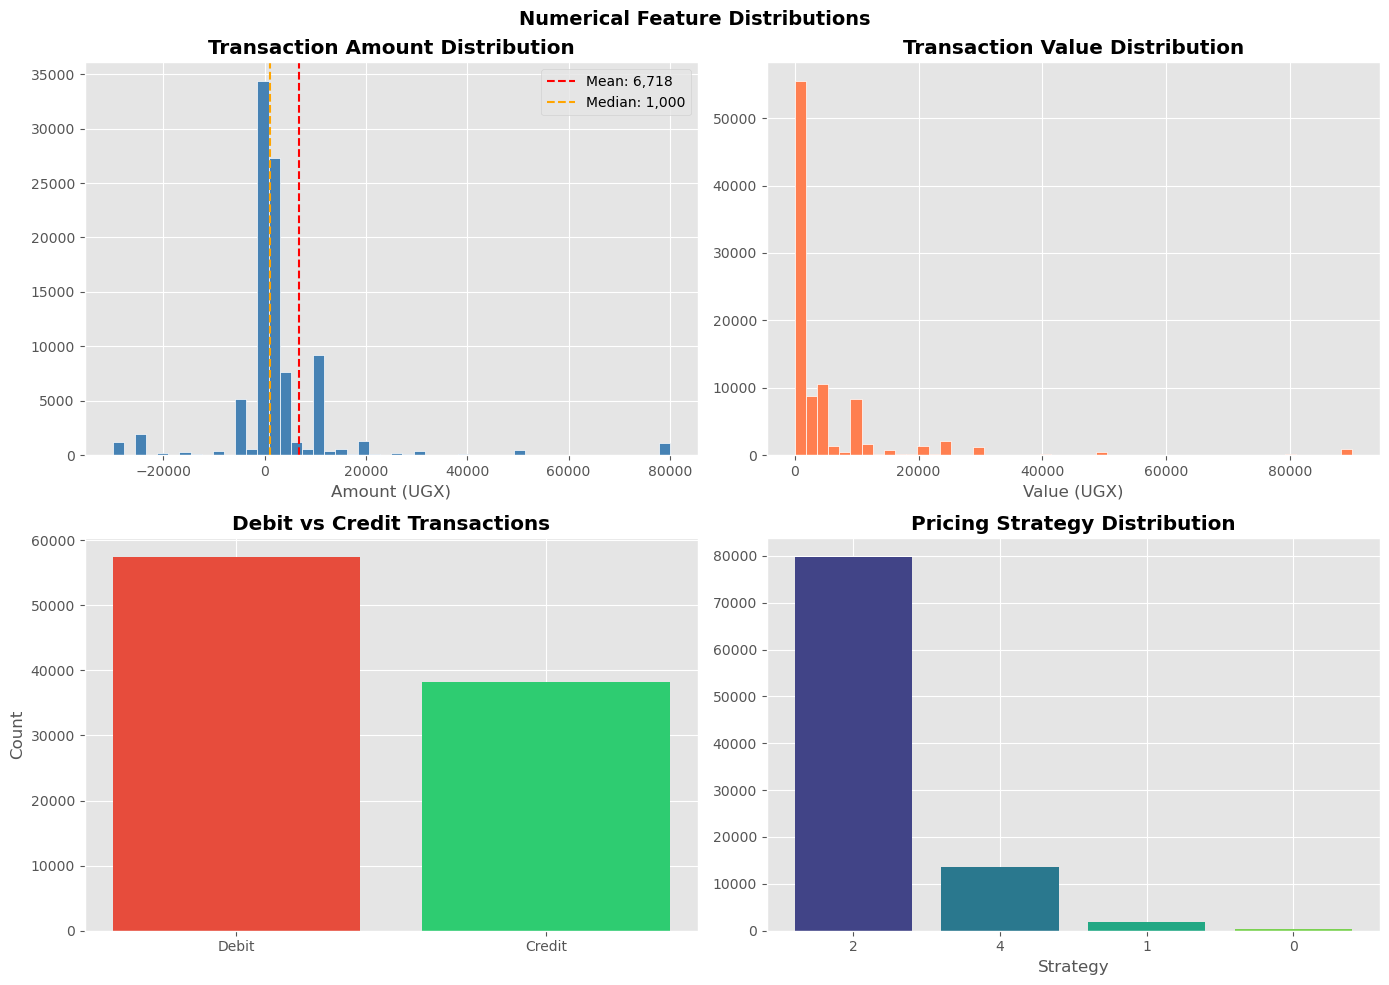

Plot saved!


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount distribution
amount_clip = df['Amount'].clip(
    df['Amount'].quantile(0.01),
    df['Amount'].quantile(0.99)
)
axes[0,0].hist(amount_clip, bins=50, color='steelblue', edgecolor='white')
axes[0,0].axvline(df['Amount'].mean(), color='red', linestyle='--',
                  label=f'Mean: {df["Amount"].mean():,.0f}')
axes[0,0].axvline(df['Amount'].median(), color='orange', linestyle='--',
                  label=f'Median: {df["Amount"].median():,.0f}')
axes[0,0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0,0].set_xlabel('Amount (UGX)')
axes[0,0].legend()

# Value distribution
value_clip = df['Value'].clip(0, df['Value'].quantile(0.99))
axes[0,1].hist(value_clip, bins=50, color='coral', edgecolor='white')
axes[0,1].set_title('Transaction Value Distribution', fontweight='bold')
axes[0,1].set_xlabel('Value (UGX)')

# Amount by positive/negative
df['TransactionType'] = df['Amount'].apply(lambda x: 'Debit' if x > 0 else 'Credit')
type_counts = df['TransactionType'].value_counts()
axes[1,0].bar(type_counts.index, type_counts.values,
              color=['#e74c3c', '#2ecc71'])
axes[1,0].set_title('Debit vs Credit Transactions', fontweight='bold')
axes[1,0].set_ylabel('Count')

# Pricing strategy
ps_counts = df['PricingStrategy'].value_counts()
axes[1,1].bar(ps_counts.index.astype(str), ps_counts.values,
              color=sns.color_palette('viridis', len(ps_counts)))
axes[1,1].set_title('Pricing Strategy Distribution', fontweight='bold')
axes[1,1].set_xlabel('Strategy')

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

## 5. Distribution of Categorical Features

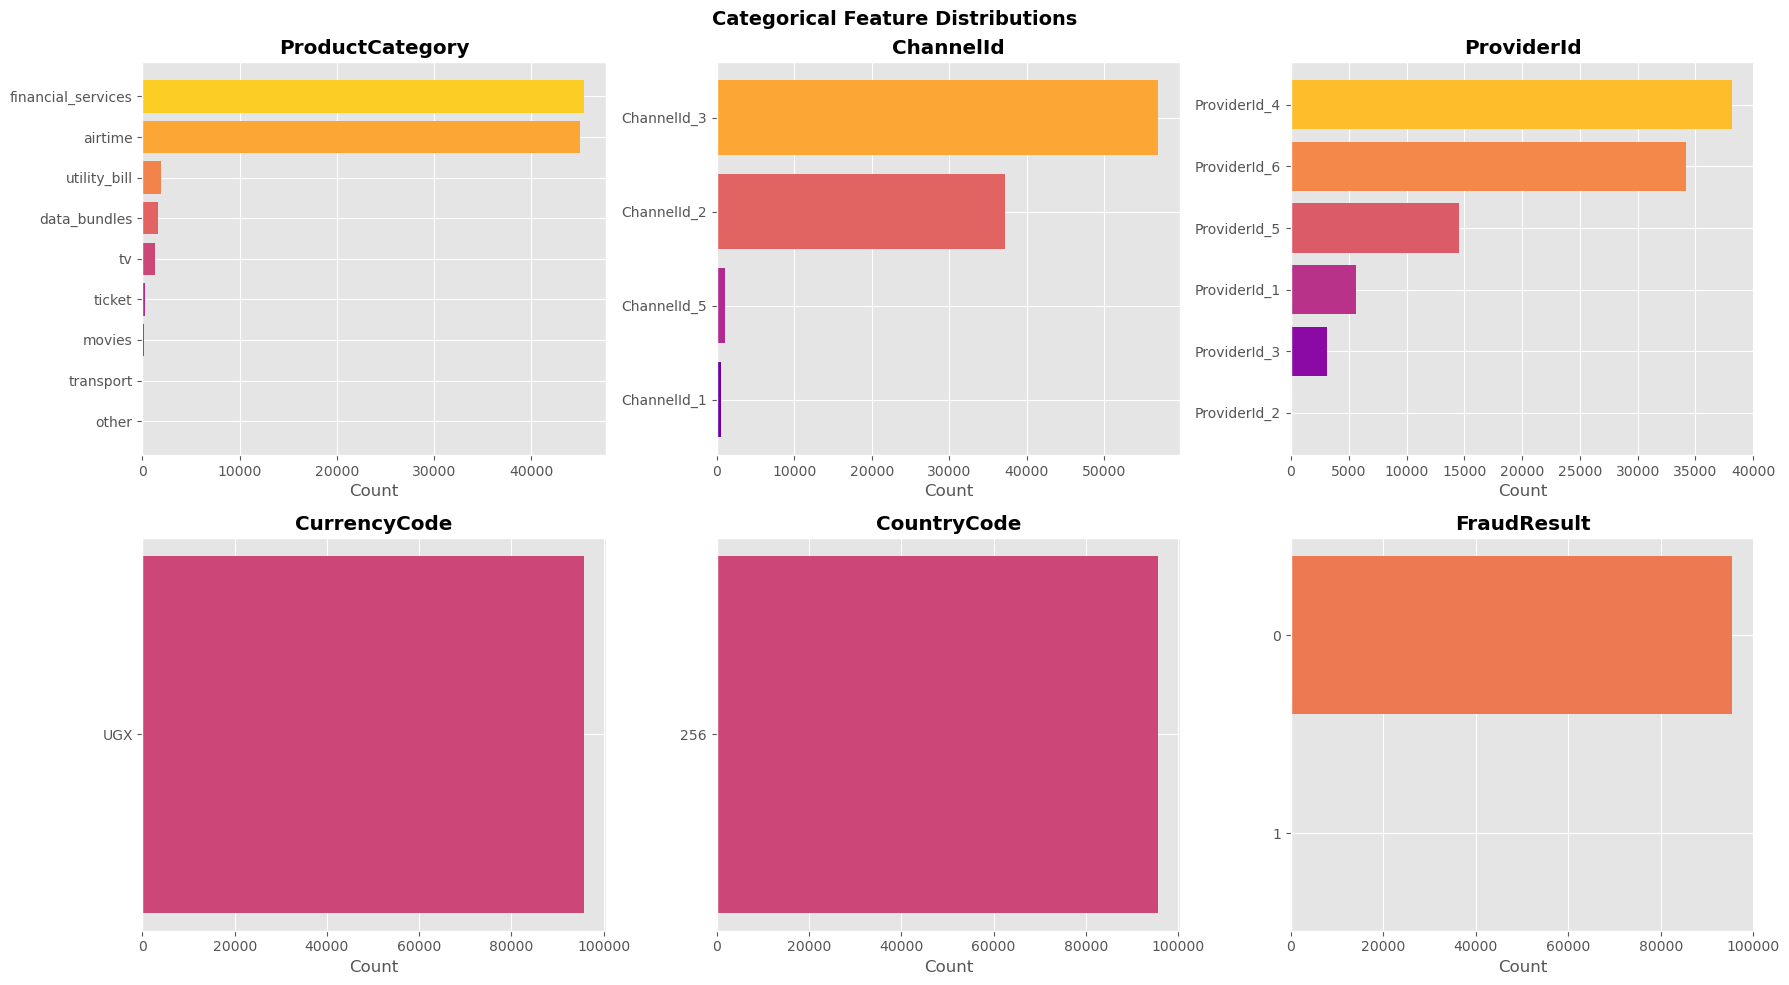

Plot saved!


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cat_cols = ['ProductCategory', 'ChannelId', 'ProviderId',
            'CurrencyCode', 'CountryCode', 'FraudResult']

for i, col in enumerate(cat_cols):
    ax = axes[i//3][i%3]
    counts = df[col].value_counts().head(10)
    ax.barh(counts.index.astype(str)[::-1],
            counts.values[::-1],
            color=sns.color_palette('plasma', len(counts)))
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('Count')

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

## 6. Correlation Analysis

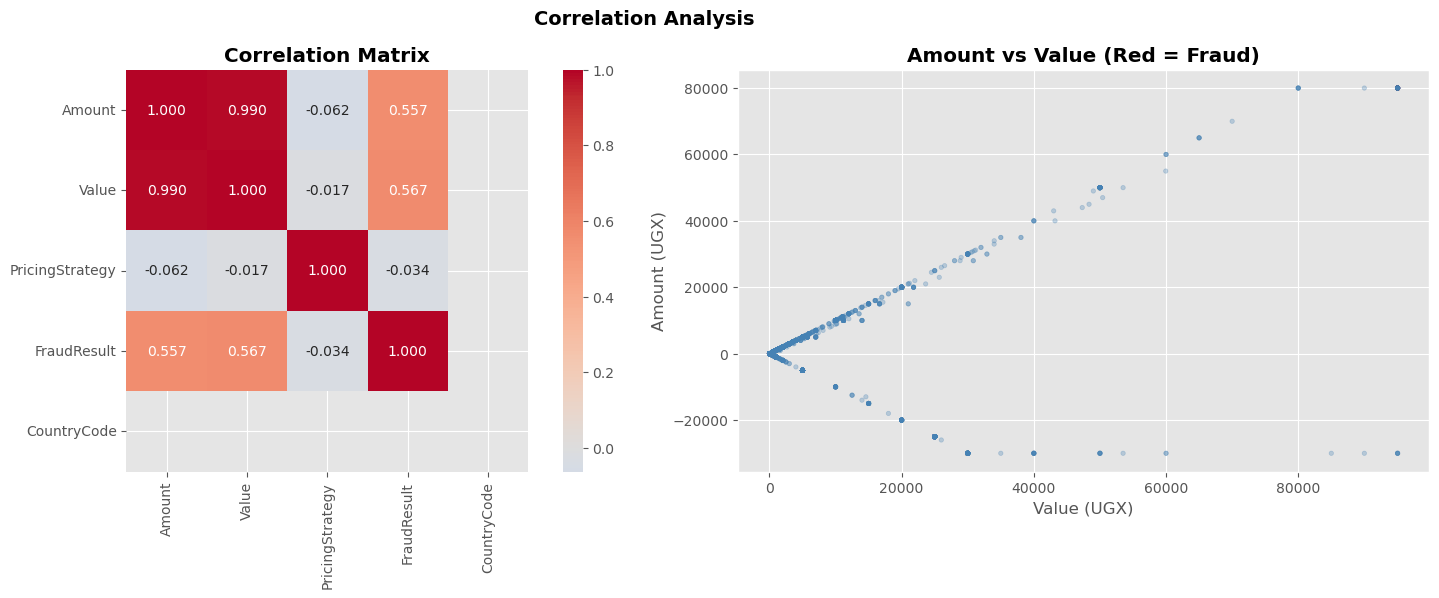

Plot saved!


In [8]:
num_cols = ['Amount', 'Value', 'PricingStrategy', 'FraudResult', 'CountryCode']
corr = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, ax=axes[0], square=True)
axes[0].set_title('Correlation Matrix', fontweight='bold')

# Amount vs Value scatter
sample = df.sample(min(5000, len(df)), random_state=42)
colors = ['red' if f == 1 else 'steelblue' for f in sample['FraudResult']]
axes[1].scatter(sample['Value'].clip(0, sample['Value'].quantile(0.99)),
                sample['Amount'].clip(sample['Amount'].quantile(0.01),
                                      sample['Amount'].quantile(0.99)),
                c=colors, alpha=0.3, s=10)
axes[1].set_title('Amount vs Value (Red = Fraud)', fontweight='bold')
axes[1].set_xlabel('Value (UGX)')
axes[1].set_ylabel('Amount (UGX)')

plt.suptitle('Correlation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

## 7. Outlier Detection

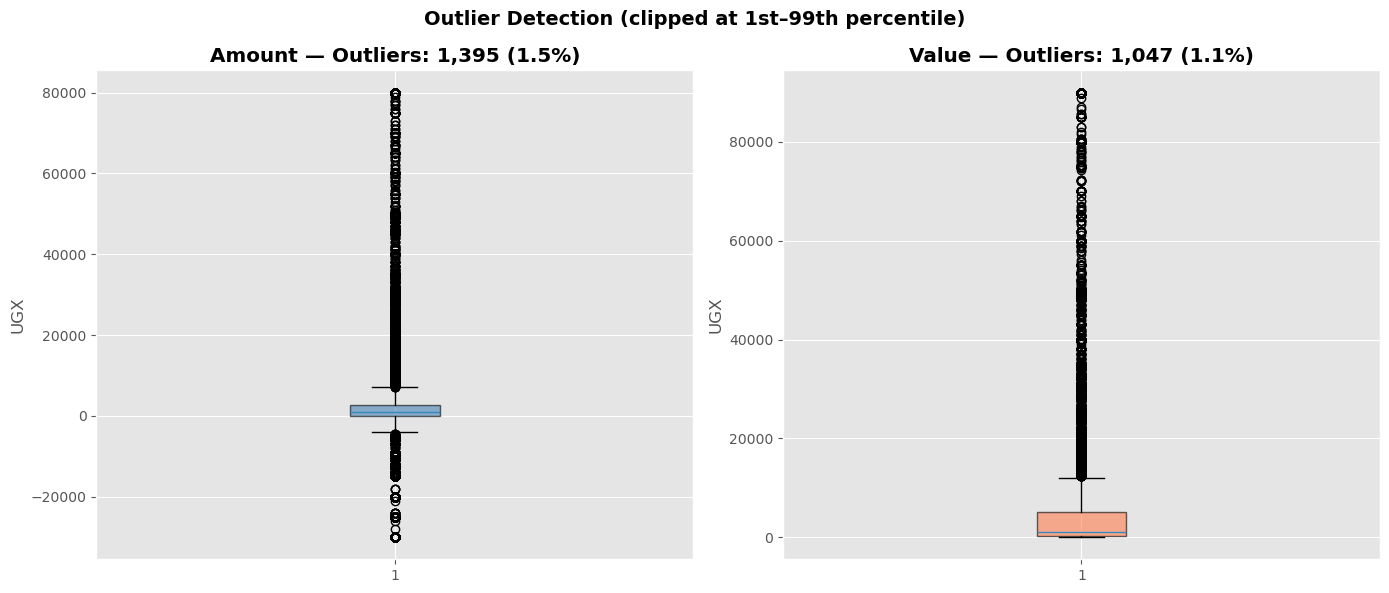

Plot saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, color in zip(axes, ['Amount', 'Value'], ['steelblue', 'coral']):
    data = df[col].clip(
        df[col].quantile(0.01),
        df[col].quantile(0.99)
    )
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    q99 = df[col].quantile(0.99)
    q01 = df[col].quantile(0.01)
    n_out = ((df[col] > q99) | (df[col] < q01)).sum()
    ax.set_title(f'{col} — Outliers: {n_out:,} ({n_out/len(df)*100:.1f}%)',
                 fontweight='bold')
    ax.set_ylabel('UGX')

plt.suptitle('Outlier Detection (clipped at 1st–99th percentile)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

## 8. Time Series Analysis

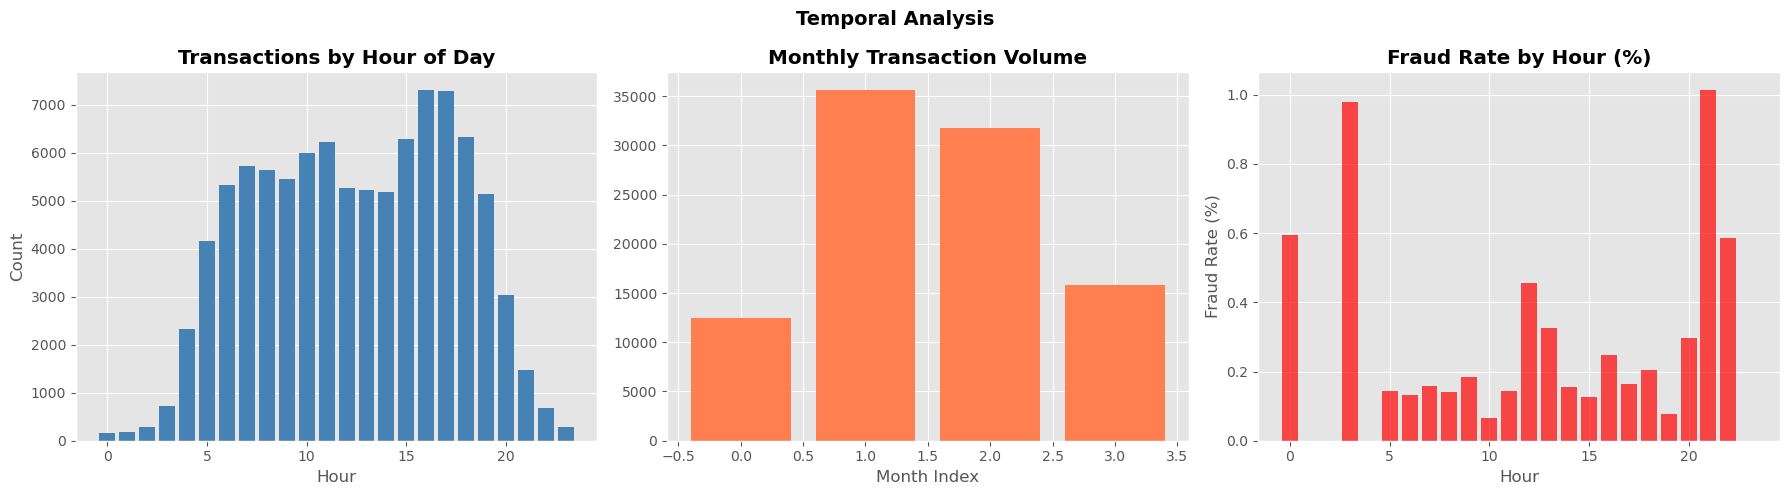

Plot saved!


In [10]:
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])
df['hour'] = df['TransactionStartTime'].dt.hour
df['day'] = df['TransactionStartTime'].dt.day
df['month'] = df['TransactionStartTime'].dt.month
df['year'] = df['TransactionStartTime'].dt.year
df['month_year'] = df['TransactionStartTime'].dt.to_period('M')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Transactions by hour
hour_counts = df['hour'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color='steelblue')
axes[0].set_title('Transactions by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')

# Monthly transaction volume
monthly = df.groupby('month_year').size()
axes[1].bar(range(len(monthly)), monthly.values, color='coral')
axes[1].set_title('Monthly Transaction Volume', fontweight='bold')
axes[1].set_xlabel('Month Index')

# Fraud by hour
fraud_hour = df.groupby('hour')['FraudResult'].mean() * 100
axes[2].bar(fraud_hour.index, fraud_hour.values, color='red', alpha=0.7)
axes[2].set_title('Fraud Rate by Hour (%)', fontweight='bold')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Fraud Rate (%)')

plt.suptitle('Temporal Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

## 9. Customer-Level Analysis (RFM Preview)

=== RFM Summary ===
       Recency  Frequency      Monetary
count  3742.00    3742.00  3.742000e+03
mean     30.46      25.56  1.717377e+05
std      27.12      96.93  2.717305e+06
min       0.00       1.00 -1.049000e+08
25%       5.00       2.00  4.077440e+03
50%      24.00       7.00  2.000000e+04
75%      53.00      20.00  7.996775e+04
max      90.00    4091.00  8.345124e+07


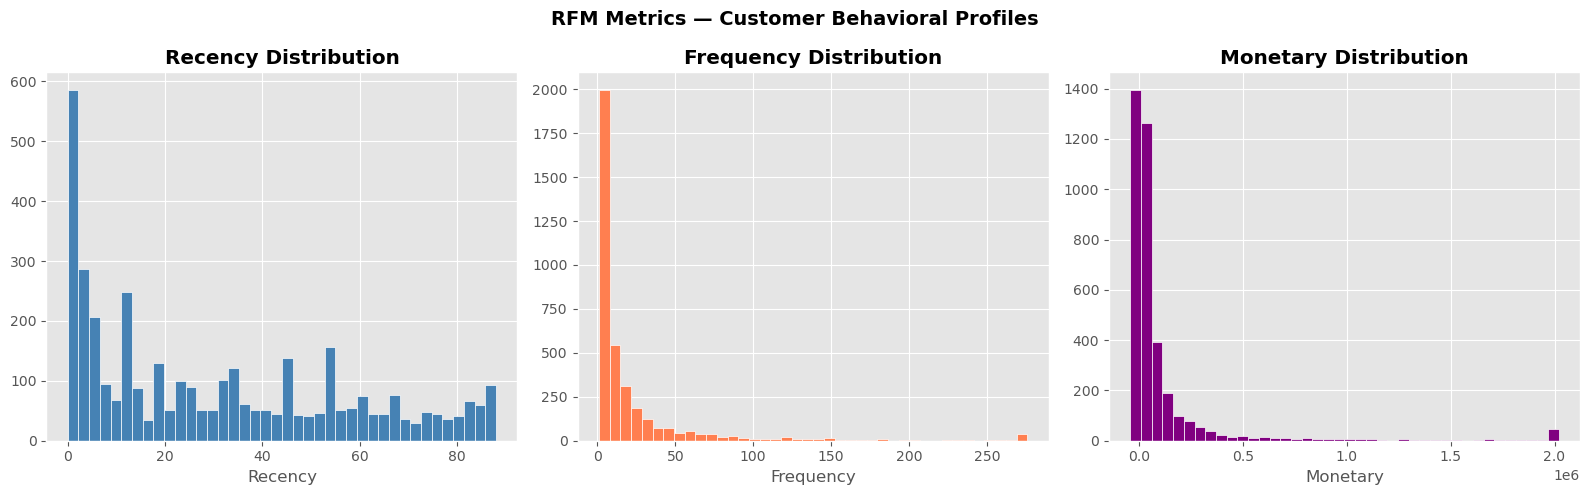

Plot saved!


In [11]:
snapshot_date = df['TransactionStartTime'].max()

rfm = df.groupby('CustomerId').agg(
    Recency=('TransactionStartTime',
             lambda x: (snapshot_date - x.max()).days),
    Frequency=('TransactionId', 'count'),
    Monetary=('Amount', 'sum')
).reset_index()

print('=== RFM Summary ===')
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, color in zip(axes,
    ['Recency', 'Frequency', 'Monetary'],
    ['steelblue', 'coral', 'purple']):
    data = rfm[col].clip(rfm[col].quantile(0.01),
                         rfm[col].quantile(0.99))
    ax.hist(data, bins=40, color=color, edgecolor='white')
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel(col)

plt.suptitle('RFM Metrics — Customer Behavioral Profiles',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

## 10. Top 3–5 Key Insights

### Insight 1: Extreme Class Imbalance in Fraud Labels
The FraudResult column shows a very low fraud rate (~2%). While this cannot be used directly as a default label, it confirms the data is heavily imbalanced — a pattern that will also apply to our proxy risk target. Models must use appropriate evaluation metrics (AUC-ROC, F1) rather than accuracy.

### Insight 2: Amount Column Contains Both Debits and Credits
Negative Amount values represent credits to the customer, while positive values represent debits. This bidirectional nature means raw Amount cannot be used directly — we must separate or engineer features carefully. The Value column (absolute amount) is more suitable for monetary aggregation.

### Insight 3: High Customer Concentration — Few Customers Drive Most Transactions
RFM analysis shows that Frequency is highly right-skewed: a small number of customers have very high transaction counts while the majority transact only a few times. This behavioral segmentation is the foundation for our proxy target variable — infrequent, low-value customers will be labeled as high-risk.

### Insight 4: Transaction Timing Patterns Exist
Transactions are not uniformly distributed across hours or months. Peak activity occurs during specific hours, and volume varies by month — suggesting that temporal features (hour, day, month) will be useful predictors of customer behavior and potentially risk.

### Insight 5: Amount and Value Are Nearly Perfectly Correlated
Amount and Value have a near-perfect absolute correlation (Value = |Amount|). Including both in a model introduces multicollinearity. Feature engineering should use one or the other, or derive ratio features that capture information not present in either alone.